In [1]:
import copernicusmarine
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm 
import numpy as np
import pandas as pd
import cartopy.crs as ccrs

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
data_request = {
   "dataset_id_plume" : "cmems_mod_glo_phy_my_0.083deg_P1D-m",
   "dataset_version": "202311",
   "longitude" : [-75, -35], 
   "latitude" : [-10, 30],
   "time" : ["2021-06-01", "2021-06-30"],
   "variables" : ["vo","uo"]
}

# Load xarray dataset
ds = copernicusmarine.open_dataset(
    dataset_id = data_request["dataset_id_plume"],
    minimum_longitude = data_request["longitude"][0],
    maximum_longitude = data_request["longitude"][1],
    minimum_latitude = data_request["latitude"][0],
    maximum_latitude = data_request["latitude"][1],
    start_datetime = data_request["time"][0],
    end_datetime = data_request["time"][1],
    variables = data_request["variables"],
    username = 'dbarreto',
    password = 'DoNuT_120197',
    chunk_size_limit = -1
)

# Print loaded dataset information
ds

INFO - 2025-08-11T13:09:12Z - Selected dataset version: "202311"
INFO - 2025-08-11T13:09:12Z - Selected dataset part: "default"


<xarray.Dataset> Size: 6GB
Dimensions:    (depth: 50, latitude: 481, longitude: 481, time: 30)
Coordinates:
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 2kB -10.0 -9.917 -9.833 ... 29.83 29.92 30.0
  * longitude  (longitude) float32 2kB -75.0 -74.92 -74.83 ... -35.08 -35.0
  * time       (time) datetime64[ns] 240B 2021-06-01 2021-06-02 ... 2021-06-30
Data variables:
    vo         (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
Attributes:
    source:       MERCATOR GLORYS12V1
    references:   http://www.mercator-ocean.fr
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    Conventions:  CF-1.4
    comment:      CMEMS product
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...
    institution:  MERCATOR OCEAN

### Calculate the W

In [14]:
## Mask calculation
ds_i = ds
_lat = ds.latitude
_lon = ds.longitude
_zt = ds.depth

ds_i = ds_i.rename({"depth": "k", "latitude":"j", "longitude":"i","uo":"uf", "vo":"vf"})
ds_i = ds_i.assign_coords(
    k=np.arange(ds_i.sizes["k"]),
    j=np.arange(ds_i.sizes["j"]),
    i=np.arange(ds_i.sizes["i"]),
    depth_t=("k", _zt.data),
    latitude_f = ("j", _lat.data),
    longitude_f = ("i", _lon.data),
)


## Calculate F and T mask
ds_i = ds_i.assign(fmask = ds_i.uf.isel(time=0,drop=True).notnull())

ds_i = ds_i.assign(
    tmask=(
        ds_i.fmask.shift(i=0,j=0)
        | ds_i.fmask.shift(i=-1,j=-1).fillna(False)
        | ds_i.fmask.shift(i=0, j=-1).fillna(False)
        | ds_i.fmask.shift(i=-1,j=-1).fillna(False)
    ).astype(bool)
)

## Calculate U and V faces
ds_i = ds_i.assign(
    u=(ds_i.uf.fillna(0) + ds_i.uf.shift(j=-1).fillna(0)) /2,
    v=(ds_i.vf.fillna(0) + ds_i.vf.shift(i=-1).fillna(0)) /2,
)

## Calculate Zt
zt = ds_i.depth_t.data
zw = [zt[0]*2]


for k in range(1,50):
    zw.append((zt[k] - zw[k-1])*2 + zw[k-1])

ds_i = ds_i.assign_coords(depth_w = ("k",zw))

ds_i = ds_i.assign_coords(
    longitude_u = ds_i.longitude_f,
    latitude_v =  ds_i.latitude_f,
    
    latitude_u = ds_i.latitude_f + 1/12/2, 
    longitude_v = ds_i.longitude_f + 1/12/2,
    
    latitude_t = ds_i.latitude_f + 1/12/2, 
    longitude_t = ds_i.longitude_f + 1/12/2,
)

R = 6371e3 

ds_i = ds_i.assign_coords(
    dz_t = ds_i.depth_w - ds_i.depth_w.shift(k=1).fillna(0), 
    dx_t = np.deg2rad(1/12) * R * np.cos(np.deg2rad(ds_i.latitude_t)),
    dy_t = np.deg2rad(1/12) * R ,
    
)

## we find the total volume flux - m3
F_uv_vol = (
    ds_i.u * ds_i.dy_t * ds_i.dz_t - ds_i.u.shift(i=-1)* ds_i.dy_t * ds_i.dz_t 
    + ds_i.v * ds_i.dx_t * ds_i.dz_t - ds_i.v.shift(j=-1) * ds_i.dx_t * ds_i.dz_t
).fillna(0)

#we divide the total flux by the volume (dx*dy*dz) - 1/s
dw_by_dz = -F_uv_vol/ds_i.dx_t/ds_i.dy_t/ds_i.dz_t

w = (dw_by_dz.fillna(0) * ds_i.dz_t.fillna(0)).cumsum('k').fillna(0).where(ds_i.tmask==1)

#we get the tmask
tmask = ds_i.tmask.compute()

w_bottom=w.isel(k=tmask.sum('k')-1)
w_correct = w - w_bottom / ds_i.dz_t.where(ds_i.tmask==1).sum('k') * ds_i.depth_w

In [15]:
w_correct

<xarray.DataArray (time: 30, k: 50, j: 481, i: 481)> Size: 3GB
dask.array<sub, shape=(30, 50, 481, 481), dtype=float64, chunksize=(2, 50, 481, 481), chunktype=numpy.ndarray>
Coordinates: (12/17)
  * time         (time) datetime64[ns] 240B 2021-06-01 2021-06-02 ... 2021-06-30
  * k            (k) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
  * j            (j) int64 4kB 0 1 2 3 4 5 6 7 ... 474 475 476 477 478 479 480
  * i            (i) int64 4kB 0 1 2 3 4 5 6 7 ... 474 475 476 477 478 479 480
    depth_t      (k) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    latitude_f   (j) float32 2kB -10.0 -9.917 -9.833 -9.75 ... 29.83 29.92 30.0
    ...           ...
    longitude_v  (i) float32 2kB -74.96 -74.88 -74.79 ... -35.12 -35.04 -34.96
    latitude_t   (j) float32 2kB -9.958 -9.875 -9.792 ... 29.88 29.96 30.04
    longitude_t  (i) float32 2kB -74.96 -74.88 -74.79 ... -35.12 -35.04 -34.96
    dz_t         (k) float32 200B 0.988 1.107 1.102 1.246 ... 435.3 447.7 458.6
    dx_t         (j) float64 4kB 9.127e+03 9.129e+03 ... 8.028e+03 8.021e+03
    dy_t         float64 8B 9.266e+03

<xarray.Dataset> Size: 14GB
Dimensions:      (time: 30, k: 50, j: 481, i: 481)
Coordinates: (12/17)
  * time         (time) datetime64[ns] 240B 2021-06-01 2021-06-02 ... 2021-06-30
  * k            (k) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
  * j            (j) int64 4kB 0 1 2 3 4 5 6 7 ... 474 475 476 477 478 479 480
  * i            (i) int64 4kB 0 1 2 3 4 5 6 7 ... 474 475 476 477 478 479 480
    depth_t      (k) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    latitude_f   (j) float32 2kB -10.0 -9.917 -9.833 -9.75 ... 29.83 29.92 30.0
    ...           ...
    longitude_v  (i) float32 2kB -74.96 -74.88 -74.79 ... -35.12 -35.04 -34.96
    latitude_t   (j) float32 2kB -9.958 -9.875 -9.792 ... 29.88 29.96 30.04
    longitude_t  (i) float32 2kB -74.96 -74.88 -74.79 ... -35.12 -35.04 -34.96
    dz_t         (k) float32 200B 0.988 1.107 1.102 1.246 ... 435.3 447.7 458.6
    dx_t         (j) float64 4kB 9.127e+03 9.129e+03 ... 8.028e+03 8.021e+03
    dy_t         float64 8B 9.266e+03
Data variables:
    vf           (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    uf           (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    fmask        (k, j, i) bool 12MB dask.array<chunksize=(50, 481, 481), meta=np.ndarray>
    tmask        (k, j, i) bool 12MB dask.array<chunksize=(50, 481, 481), meta=np.ndarray>
    u            (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    v            (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    w_c          (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
Attributes:
    source:       MERCATOR GLORYS12V1
    references:   http://www.mercator-ocean.fr
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    Conventions:  CF-1.4
    comment:      CMEMS product
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...
    institution:  MERCATOR OCEAN

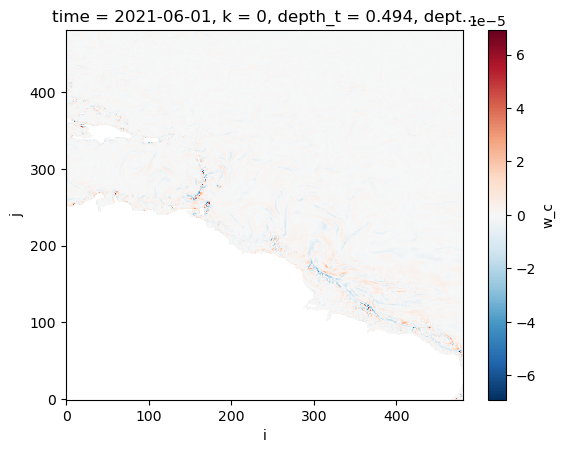

In [16]:
ds_i['w_c'] = w_correct
ds_i.w_c.isel(time=0,k=0).plot()
ds_i

In [17]:
#1. We insert the 0m at z
# z = np.insert(ds_i.depth_t.values,0,0.001)
k=np.arange(0,51,1)

#2. We linearly interpolate the U,V
ds_i_= ds_i.interp(k=np.arange(0,50,1))
ds_i_['w_c'][..., 0, :, :] = 0
ds_i_['u'][..., 0, :, :] = ((ds_i.u.isel(k=0) * 0.001)/ds_i.depth_t.isel(k=0)).isel(time=0)
ds_i_['v'][..., 0, :, :] = ((ds_i.v.isel(k=0) * 0.001)/ds_i.depth_t.isel(k=0)).isel(time=0)
ds_i_

<xarray.Dataset> Size: 14GB
Dimensions:      (time: 30, k: 50, j: 481, i: 481)
Coordinates: (12/17)
    time         (time) datetime64[ns] 240B 2021-06-01 2021-06-02 ... 2021-06-30
  * j            (j) int64 4kB 0 1 2 3 4 5 6 7 ... 474 475 476 477 478 479 480
  * i            (i) int64 4kB 0 1 2 3 4 5 6 7 ... 474 475 476 477 478 479 480
    depth_t      (k) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
    latitude_f   (j) float32 2kB -10.0 -9.917 -9.833 -9.75 ... 29.83 29.92 30.0
    longitude_f  (i) float32 2kB -75.0 -74.92 -74.83 ... -35.17 -35.08 -35.0
    ...           ...
    latitude_t   (j) float32 2kB -9.958 -9.875 -9.792 ... 29.88 29.96 30.04
    longitude_t  (i) float32 2kB -74.96 -74.88 -74.79 ... -35.12 -35.04 -34.96
    dz_t         (k) float32 200B 0.988 1.107 1.102 1.246 ... 435.3 447.7 458.6
    dx_t         (j) float64 4kB 9.127e+03 9.129e+03 ... 8.028e+03 8.021e+03
    dy_t         float64 8B 9.266e+03
  * k            (k) int64 400B 0 1 2 3 4 5 6 7 8 ... 41 42 43 44 45 46 47 48 49
Data variables:
    vf           (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    uf           (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    u            (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    v            (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    w_c          (time, k, j, i) float64 3GB dask.array<chunksize=(2, 50, 481, 481), meta=np.ndarray>
    fmask        (k, j, i) bool 12MB dask.array<chunksize=(50, 481, 481), meta=np.ndarray>
    tmask        (k, j, i) bool 12MB dask.array<chunksize=(50, 481, 481), meta=np.ndarray>
Attributes:
    source:       MERCATOR GLORYS12V1
    references:   http://www.mercator-ocean.fr
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    Conventions:  CF-1.4
    comment:      CMEMS product
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...
    institution:  MERCATOR OCEAN

### Let's run parcels

In [18]:
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
import numpy as np
from parcels import FieldSet

In [26]:
num_particles = 100
run_time_days = 20
time_step_minutes = 20
out_put_step_hours = 6

#initial position
lon0 = -50
lon1 = -48
lat0 = 1
lat1 = -0.5

depth_min = 1 #todo: figure near-surface depths 
depth_max = 10

out_path = './'

In [21]:
start_time = "2022-06-01T00:00:00"

#reproducibility
rdm_seed = 1234

In [22]:
## now the fieldset
fieldset = FieldSet.from_xarray_dataset(
    ds_i_,
    
    variables = {
    "U": "uf",
    "V": "vf",
    "W": "w_c"
    },

    interp_method = {
    "U":"cgrid_velocity",
    "V":"cgrid_velocity",
    "W":"cgrid_velocity",
    },
    
    dimensions = {
    "U": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"},
    "V": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"},
    "W": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"}
    },
    
    time_periodic=False,
    allow_time_extrapolation=True,
    gridindexingtype = "nemo",
)

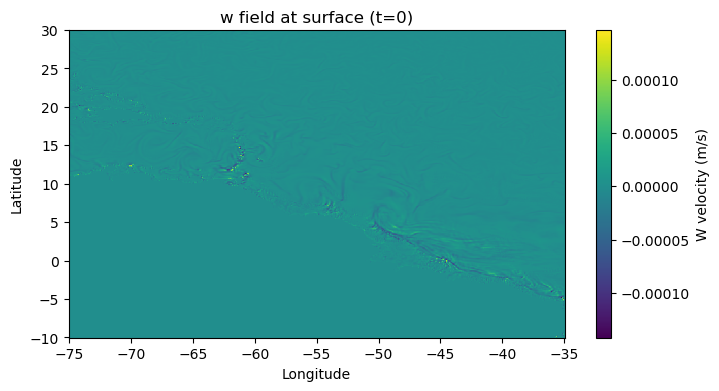

In [23]:
w = fieldset.W.data[0, 1, :, :] 


lon = fieldset.W.grid.lon
lat = fieldset.W.grid.lat

plt.figure(figsize=(8, 4))
plt.pcolormesh(lon, lat, w, shading='auto')
plt.colorbar(label='W velocity (m/s)')
plt.title("w field at surface (t=0)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [24]:
##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [25]:
## Time and depth initial conditios
start_pos_along_line = np.random.uniform(0,1,size=num_particles)
start_lon = lon0 + start_pos_along_line * (lon1-lon0)
start_lat = lat0 + start_pos_along_line * (lat1-lat0)
start_depth = np.random.uniform(depth_min,depth_max,size=num_particles)
start_times = np.datetime64(start_time)

In [27]:
# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    lon = start_lon,
    lat = start_lat,
    depth=start_depth,
    time=start_times
) 


out_fn = f'Parcels_run_{rdm_seed}_{start_time}.zarr'

output_file = pset.ParticleFile(
    name=out_path+out_fn,
    outputdt=timedelta(hours=out_put_step_hours),
    chunks = (num_particles,int(run_time_days*24/out_put_step_hours/4))
)

In [30]:
## Execute particles
pset.execute(
    [AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=run_time_days),
    dt=timedelta(minutes=time_step_minutes),
    output_file= output_file
)

INFO: Output files are stored in ./Parcels_run_1234_2022-06-01T00:00:00.zarr.
100%|██████████| 1728000.0/1728000.0 [02:19<00:00, 12401.65it/s] 


In [38]:
ds_traj = xr.open_zarr(out_path+out_fn)
# ds_traj = ds_traj.compute()
ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 257kB
Dimensions:     (trajectory: 100, obs: 80)
Coordinates:
  * obs         (obs) int32 320B 0 1 2 3 4 5 6 7 8 ... 72 73 74 75 76 77 78 79
  * trajectory  (trajectory) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
Data variables:
    lat         (trajectory, obs) float64 64kB 0.7413 0.7564 ... 0.5488 0.5488
    lon         (trajectory, obs) float64 64kB -48.97 -48.97 ... -48.21 -48.21
    time        (trajectory, obs) datetime64[ns] 64kB 2022-06-01 ... 2022-06-...
    z           (trajectory, obs) float64 64kB 5.79 5.866 5.95 ... 26.82 26.84
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [43]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

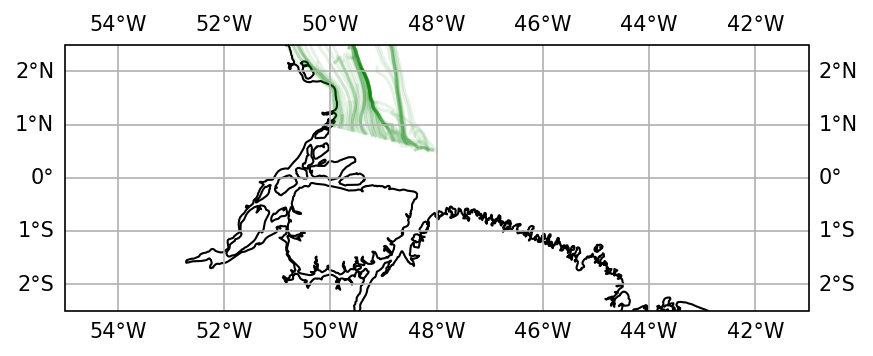

In [46]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
fig.set_dpi(150)

for n in range(ds_traj.sizes["trajectory"]):
    ax.plot(
        *ds_traj.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="g", alpha=0.1,
        transform=ccrs.PlateCarree(),
    )

ax.coastlines()
ax.set_extent([
    -55,
    -41,
    -2.5,
    2.5,
])
ax.gridlines(draw_labels=True);


In [54]:
#initial position
lon0 = -50
lon1 = -48
lat0 = 1
lat1 = -0.5

start_pos_along_line = np.random.uniform(0,1,size=num_particles)
start_lon = lon0 + start_pos_along_line * (lon1-lon0)
start_lat = lat0 + start_pos_along_line * (lat1-lat0)

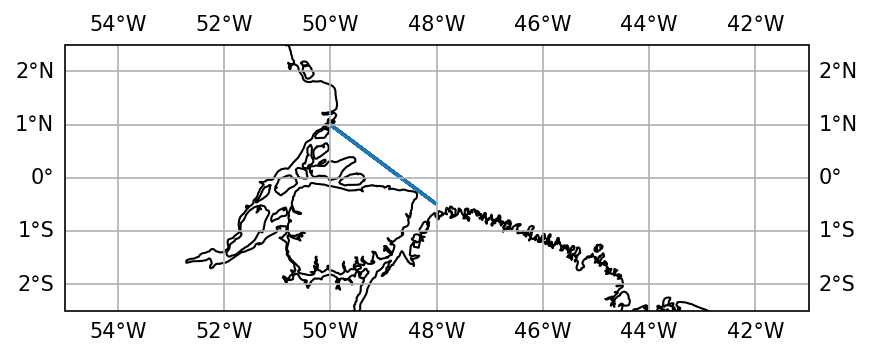

In [55]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
fig.set_dpi(150)

plt.plot(start_lon,start_lat)

ax.coastlines()
ax.set_extent([
    -55,
    -41,
    -2.5,
    2.5,
])
ax.gridlines(draw_labels=True);